<a href="https://colab.research.google.com/github/NasserYQ/Saudi-Female-Owned-enterprises-2030/blob/main/Female_Owned_Enterprises_2030.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🇸🇦 Female-Owned Enterprises in Saudi Arabia — Forecast to 2030

**Project Goal:** Analyze quarterly data of female-owned enterprises across all Saudi regions and build a machine learning model to predict the total count by 2030.

---

## 📋 Table of Contents
1. Libraries & Setup
2. Load & Merge Data
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Visualization
6. ML Model — Forecast to 2030
7. Results Summary

---

## 📦 Dataset Info
| File | Quarter | Rows |
|---|---|---|
| Female_Owned_Enterprises_First_Quarter_CSV.csv | Q1 2025 | 6,801 |
| Female_Owned_Enterprises_Second_Quarter_CSV.csv | Q2 2025 | 6,801 |
| Female_Owned_Enterprises_Third_Quarter_CSV.csv | Q3 2025 | 6,801 |
| Female_Owned_Enterprises_Fourth_Quarter_CSV.csv | Q4 2025 | 3,311 |

---
## Step 1 — Libraries & Setup

### 📚 What we import and WHY

| Library | What it does | What we use from it |
|---|---|---|
| `pandas` | Load, clean, and manipulate tabular data (like Excel in Python) | `read_csv`, `concat`, `groupby`, `dropna`, `rename` |
| `numpy` | Fast math operations on arrays | `np.sqrt`, `np.arange` |
| `matplotlib.pyplot` | Base plotting engine | `plt.subplots`, `plt.savefig`, `plt.show` |
| `seaborn` | Beautiful statistical charts built on top of matplotlib | `sns.set_theme`, `sns.barplot`, `sns.heatmap` |
| `sklearn.linear_model` | Machine learning models | `LinearRegression` |
| `sklearn.metrics` | Measure model accuracy | `r2_score`, `mean_squared_error` |

In [3]:
# ── Standard libraries ──────────────────────────────────────────
import pandas as pd                          # Data manipulation
import numpy as np                           # Numerical operations

# ── Visualization ───────────────────────────────────────────────
import matplotlib.pyplot as plt              # Core plotting
import matplotlib.ticker as mticker          # Axis formatting
import seaborn as sns                        # Statistical charts

# ── Machine Learning ────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# ── Settings ────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Color palette for charts
PALETTE = ['#C8102E', '#006C35', '#1A5276', '#F39C12', '#8E44AD']

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


---
## Step 2 — Load & Merge Data

### 🔧 Pandas Methods Used Here

| Method | What it does |
|---|---|
| `pd.read_csv(path)` | Reads a CSV file and returns a DataFrame |
| `df.columns.str.strip()` | Removes leading/trailing whitespace from column names |
| `pd.concat([df1, df2, ...])` | Stacks multiple DataFrames vertically into one |
| `df.shape` | Returns `(rows, columns)` — the size of the DataFrame |
| `df.head(n)` | Shows the first `n` rows |

> ⚠️ **Colab tip:** Upload all 4 CSV files first via the 📁 sidebar → Upload, then run this cell.

In [5]:
# ── File paths (update if your folder is different) ─────────────
files = {
    'Q1': '/content/drive/MyDrive/Datasets/EMA_2025/Female_Owned_Enterprises_First_Quarter.csv',
    'Q2': '/content/drive/MyDrive/Datasets/EMA_2025/Female_Owned_Enterprises_Second_Quarter.csv',
    'Q3': '/content/drive/MyDrive/Datasets/EMA_2025/Female_Owned_Enterprises_Third_Quarter.csv',
    'Q4': '/content/drive/MyDrive/Datasets/EMA_2025/Female_Owned_Enterprises_Fourth_Quarter.csv',
}

# ── Load each file and store in a list ──────────────────────────
frames = []

for quarter, filename in files.items():
    df_q = pd.read_csv(filename)             # pd.read_csv → reads CSV into DataFrame
    df_q.columns = df_q.columns.str.strip()  # .str.strip() → removes extra spaces in column names
    frames.append(df_q)
    print(f'  ✓ {quarter} loaded — {df_q.shape[0]:,} rows')  # .shape[0] → row count

# ── Stack all quarters into one DataFrame ───────────────────────
# pd.concat() joins them vertically (row by row)
# ignore_index=True resets the row numbers (0, 1, 2, ...) instead of keeping each file's index
df_raw = pd.concat(frames, ignore_index=True)

print(f'\n📦 Total rows after merging : {df_raw.shape[0]:,}')
print(f'📦 Total columns             : {df_raw.shape[1]}')
print('\nFirst 3 rows:')
df_raw.head(3)  # .head(n) → shows first n rows

  ✓ Q1 loaded — 6,801 rows
  ✓ Q2 loaded — 6,801 rows
  ✓ Q3 loaded — 6,801 rows
  ✓ Q4 loaded — 3,311 rows

📦 Total rows after merging : 23,714
📦 Total columns             : 16

First 3 rows:


,السنة,الربع,المنطقة,النشاط الاقتصادي - المستوى الثاني,حجم المنشأة,عدد المنشآت المملوكة للمرأة,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,2025.0,1.0,المنطقة الشرقية,غير معرف,صغيرة,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025.0,1.0,منطقة الجوف,غير معرف,صغيرة,2.0,NaN,اخلاء مسؤولية:\n - تمت معالجة البيانات بأقصى ق...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025.0,1.0,منطقة الرياض,غير معرف,صغيرة,418.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## Step 3 — Data Cleaning

Raw data is almost never ready to use. We need to:
1. **Select** only the useful columns
2. **Rename** columns to English (easier to work with)
3. **Drop** missing values (`NaN`)
4. **Fix** data types (numbers stored as text, etc.)
5. **Engineer** a new feature: `time_index`

### 🔧 Pandas Methods Used Here

| Method | What it does |
|---|---|
| `df[list_of_cols]` | Selects specific columns only |
| `df.copy()` | Creates an independent copy (avoids modifying the original) |
| `df.rename(columns={...})` | Renames columns using a dictionary |
| `df.isnull().sum()` | Counts missing values per column |
| `df.dropna()` | Removes rows that have any missing value |
| `df['col'].astype(type)` | Converts a column to a specific data type |
| `df.info()` | Shows column names, types, and non-null counts |
| `df.describe()` | Summary statistics (mean, std, min, max, etc.) |

In [6]:
# ── 3a. Select only the 6 useful columns ────────────────────────
COLUMN_MAP = {
    'السنة'                                 : 'year',
    'الربع'                                 : 'quarter',
    'المنطقة'                               : 'region',
    'النشاط الاقتصادي - المستوى الثاني'     : 'activity',
    'حجم المنشأة'                           : 'size',
    'عدد المنشآت المملوكة للمرأة'           : 'count',
}

# df[list] → selects specific columns
# .copy()  → makes an independent copy so we don't modify df_raw
df = df_raw[list(COLUMN_MAP.keys())].copy()

# ── 3b. Rename Arabic columns to English ────────────────────────
# .rename(columns=dict) → renames columns using old:new mapping
df.rename(columns=COLUMN_MAP, inplace=True)  # inplace=True → modifies df directly

print('── Missing values BEFORE cleaning ──')
print(df.isnull().sum())   # .isnull() → True where value is NaN
                            # .sum()    → counts Trues per column

# ── 3c. Drop rows with missing values ───────────────────────────
# .dropna() → removes any row that has at least one NaN
df.dropna(inplace=True)

print(f'\n── Missing values AFTER cleaning ──')
print(df.isnull().sum())
print(f'\n✅ Clean rows: {df.shape[0]:,}')

── Missing values BEFORE cleaning ──
year        10645
quarter     10645
region      10645
activity    10645
size        10645
count       10645
dtype: int64

── Missing values AFTER cleaning ──
year        0
quarter     0
region      0
activity    0
size        0
count       0
dtype: int64

✅ Clean rows: 13,069


In [7]:
# ── 3d. Fix data types ───────────────────────────────────────────
# .astype(type) → converts column to the specified type
# Why? After reading CSV, numbers can be stored as float or object (string)
df['year']    = df['year'].astype(int)     # float → int  (no decimals needed)
df['quarter'] = df['quarter'].astype(int)  # float → int
df['count']   = df['count'].astype(int)    # float → int

# ── 3e. Feature Engineering: time_index ─────────────────────────
# Linear Regression needs a single numeric input.
# We create time_index = year * 4 + quarter
# Example: 2025-Q1 → 2025*4+1 = 8101
#          2025-Q2 → 2025*4+2 = 8102  (always increasing by 1)
df['time_index'] = df['year'] * 4 + df['quarter']

# ── 3f. Verify ───────────────────────────────────────────────────
print('── Data types after cleaning ──')
df.info()   # .info() → shows column names, dtypes, non-null counts

print('\n── Statistical summary ──')
df.describe()  # .describe() → min, max, mean, std, quartiles

── Data types after cleaning ──
<class 'pandas.core.frame.DataFrame'>
Index: 13069 entries, 0 to 23713
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   year        13069 non-null  int64 
 1   quarter     13069 non-null  int64 
 2   region      13069 non-null  object
 3   activity    13069 non-null  object
 4   size        13069 non-null  object
 5   count       13069 non-null  int64 
 6   time_index  13069 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 816.8+ KB

── Statistical summary ──


,year,quarter,count,time_index
count,13069.0,13069.000000,13069.000000,13069.000000
mean,2025.0,2.511363,221.575407,8102.511363
std,0.0,1.118053,2006.301844,1.118053
min,2025.0,1.000000,1.000000,8101.000000
25%,2025.0,2.000000,2.000000,8102.000000
50%,2025.0,3.000000,6.000000,8103.000000
75%,2025.0,4.000000,29.000000,8104.000000
max,2025.0,4.000000,124657.000000,8104.000000


---
## Step 4 — Exploratory Data Analysis (EDA)

Before modeling, we explore the data to understand:
- How the total count changes each quarter
- Which regions have the most female-owned enterprises
- What sizes and sectors dominate

### 🔧 Pandas Methods Used Here

| Method | What it does |
|---|---|
| `df.groupby(col)` | Groups rows by a column's value |
| `.sum()` / `.mean()` / `.count()` | Aggregation: total / average / count per group |
| `.reset_index()` | Converts groupby result back to a normal DataFrame |
| `.sort_values(ascending=...)` | Sorts rows by a column |
| `df['col'].nunique()` | Counts distinct (unique) values in a column |
| `df['col'].unique()` | Lists all distinct values |
| `df['col'].value_counts()` | Counts how many times each value appears |
| `df.corr()` | Correlation matrix between all numeric columns |

In [8]:
# ── 4a. Total enterprises per quarter ───────────────────────────
# .groupby(['year','quarter']) → group rows by year AND quarter
# ['count'].sum()              → sum the count column within each group
# .reset_index()               → turn result back into a flat DataFrame
quarterly = (
    df.groupby(['year', 'quarter'])['count']
      .sum()
      .reset_index()
      .sort_values(['year', 'quarter'])  # .sort_values() → sort rows
)

# Create a readable label and a numeric time_index for ML
quarterly['label']      = quarterly['year'].astype(str) + '-Q' + quarterly['quarter'].astype(str)
quarterly['time_index'] = quarterly['year'] * 4 + quarterly['quarter']

print('── Total enterprises per quarter ──')
print(quarterly[['label', 'count']].to_string(index=False))

── Total enterprises per quarter ──
  label  count
2025-Q1 682598
2025-Q2 709779
2025-Q3 729269
2025-Q4 774123


In [9]:
# ── 4b. By region ────────────────────────────────────────────────
# .nunique() → how many distinct values
print(f'Total regions in dataset: {df["region"].nunique()}')
print(f'Total activities        : {df["activity"].nunique()}')
print(f'Enterprise sizes        : {df["size"].unique()}\n')

top_regions = (
    df.groupby('region')['count']
      .sum()
      .sort_values(ascending=False)  # highest first
)
print('── Total enterprises by region ──')
print(top_regions.to_string())

Total regions in dataset: 13
Total activities        : 89
Enterprise sizes        : ['صغيرة' 'متناهية الصغر' 'متوسطة' 'كبيرة']

── Total enterprises by region ──
region
منطقة الرياض             1282147
منطقة مكة المكرمة         478927
المنطقة الشرقية           306941
منطقة عسير                150906
منطقة القصيم              140594
منطقة المدينة المنورة     136060
منطقة جازان               102622
منطقة حائل                 74790
منطقة تبوك                 66701
منطقة نجران                63850
منطقة الجوف                39314
منطقة الحدود الشمالية      32431
منطقة الباحة               20486


In [10]:
# ── 4c. By enterprise size ────────────────────────────────────────
size_dist = (
    df.groupby('size')['count']
      .sum()
      .sort_values(ascending=False)
)
print('── Distribution by enterprise size ──')
print(size_dist.to_string())

# ── 4d. Top 8 economic activities ────────────────────────────────
top_activities = (
    df.groupby('activity')['count']
      .sum()
      .sort_values(ascending=False)
      .head(8)  # .head(n) → top n rows
)
print('\n── Top 8 economic activities ──')
print(top_activities.to_string())

── Distribution by enterprise size ──
size
متناهية الصغر    2706698
صغيرة             169908
متوسطة             16827
كبيرة               2336

── Top 8 economic activities ──
activity
تشييد المباني                                                             466237
غير معرف                                                                  425947
تجارة التجزئة، باستثناء المركبات ذات المحركات والدراجات النارية           378482
أنشطة خدمات الأطعمة والمشروبات                                            236205
أنشطة الخدمات الشخصية الأخرى                                              161410
أنشطة التشييد المتخصصة                                                    154209
تجارة الجملة والتجزئة ، وإصلاح المركبات ذات المحركات والدراجات النارية    144107
تجارة الجملة ، باستثناء المركبات ذات المحركات والدراجات النارية           112247


In [ ]:
# ── 4e. Correlation ───────────────────────────────────────────────
# .corr() → Pearson correlation between numeric columns (-1 to +1)
# 1.0  = perfect positive relationship
# -1.0 = perfect negative relationship
# 0.0  = no relationship
print('── Correlation between numeric columns ──')
print(df[['year', 'quarter', 'count', 'time_index']].corr())

---
## Step 5 — Visualization

### 🎨 Matplotlib & Seaborn — What we use

| Function | Library | What it draws |
|---|---|---|
| `plt.subplots(rows, cols)` | matplotlib | Creates a grid of chart panels |
| `ax.bar(x, y)` | matplotlib | Vertical bar chart |
| `ax.barh(y, x)` | matplotlib | Horizontal bar chart |
| `ax.pie(values)` | matplotlib | Pie chart |
| `ax.plot(x, y)` | matplotlib | Line chart |
| `ax.set_title()` | matplotlib | Sets chart title |
| `ax.set_xlabel/ylabel()` | matplotlib | Axis labels |
| `sns.heatmap(df.corr())` | seaborn | Correlation heatmap |
| `plt.tight_layout()` | matplotlib | Auto-fixes spacing between panels |
| `plt.show()` | matplotlib | Renders the chart in Colab |

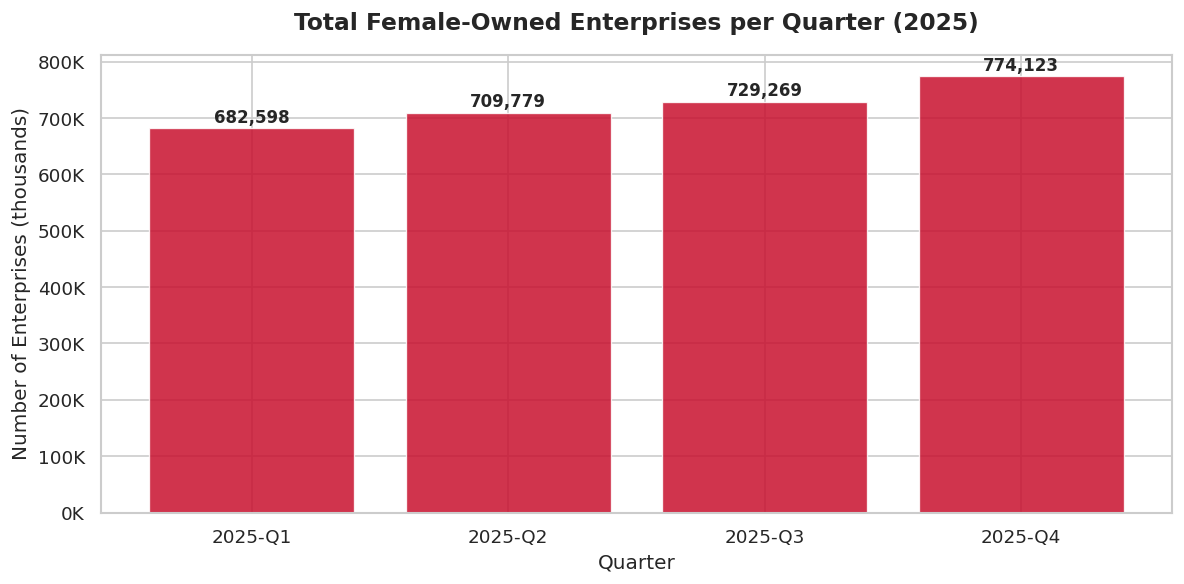

In [11]:
# ── Chart 1: Quarterly trend ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))  # figsize=(width, height) in inches

bars = ax.bar(
    quarterly['label'],          # x-axis: quarter labels
    quarterly['count'] / 1000,   # y-axis: count in thousands
    color=PALETTE[0],
    alpha=0.85,                  # transparency (0=invisible, 1=solid)
    edgecolor='white',
    linewidth=0.8
)

# Add value labels on top of each bar
for bar, val in zip(bars, quarterly['count']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x center of bar
        bar.get_height() + 3,               # slightly above bar
        f'{val:,}',                          # formatted number
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Total Female-Owned Enterprises per Quarter (2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Quarter')
ax.set_ylabel('Number of Enterprises (thousands)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
plt.tight_layout()  # auto-adjusts spacing
plt.show()

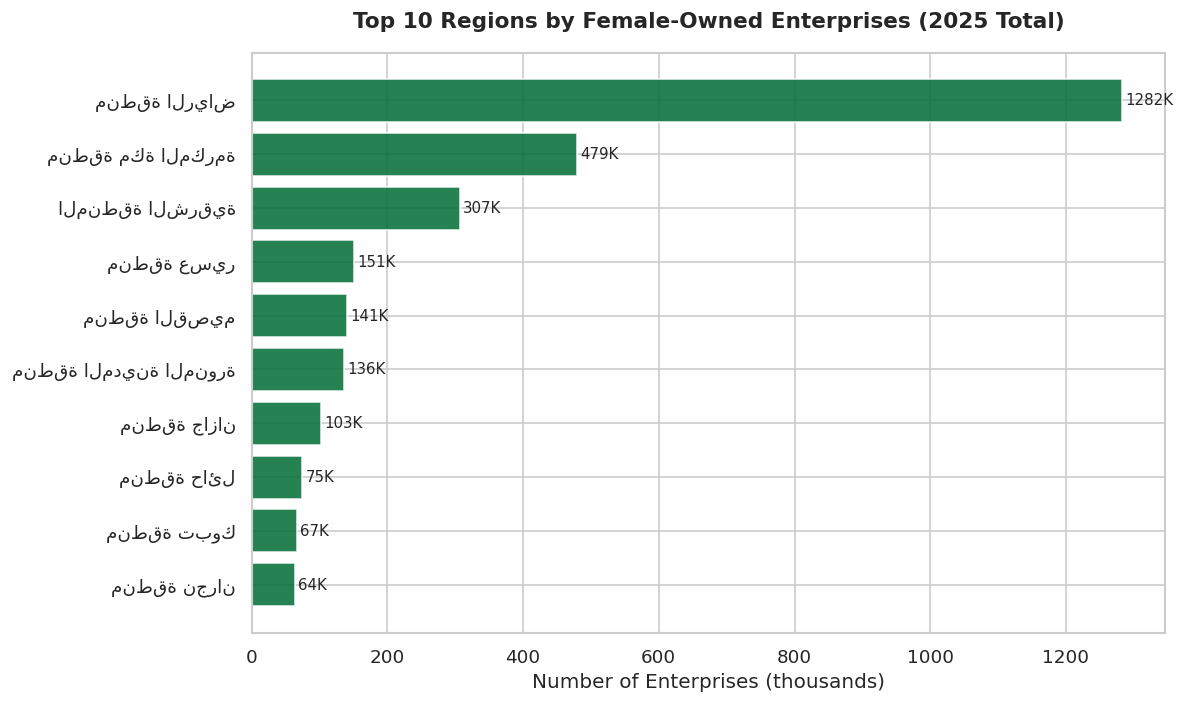

In [12]:
# ── Chart 2: Top regions (horizontal bar) ────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# .tail(10) → last 10 (since sorted ascending, these are the highest)
top10 = top_regions.sort_values(ascending=True).tail(10)

bars = ax.barh(top10.index, top10.values / 1000, color=PALETTE[1], alpha=0.85, edgecolor='white')

# Add value labels
for bar, val in zip(bars, top10.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val/1000:.0f}K', va='center', fontsize=9)

ax.set_title('Top 10 Regions by Female-Owned Enterprises (2025 Total)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Number of Enterprises (thousands)')
plt.tight_layout()
plt.show()

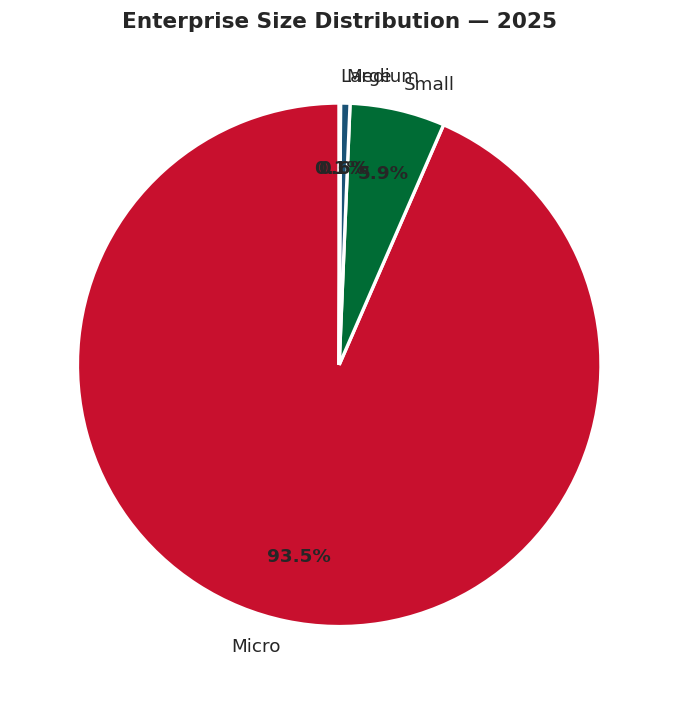

In [13]:
# ── Chart 3: Enterprise size distribution (pie) ───────────────────
# Translate sizes to English
size_en = {
    'متناهية الصغر': 'Micro',
    'صغيرة':         'Small',
    'متوسطة':        'Medium',
    'كبيرة':         'Large',
}
size_dist_en = size_dist.copy()
size_dist_en.index = [size_en.get(s, s) for s in size_dist_en.index]

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    size_dist_en.values,
    labels=size_dist_en.index,
    autopct='%1.1f%%',          # show % with 1 decimal
    colors=PALETTE,
    startangle=90,              # rotate so largest slice is at top
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

ax.set_title('Enterprise Size Distribution — 2025', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

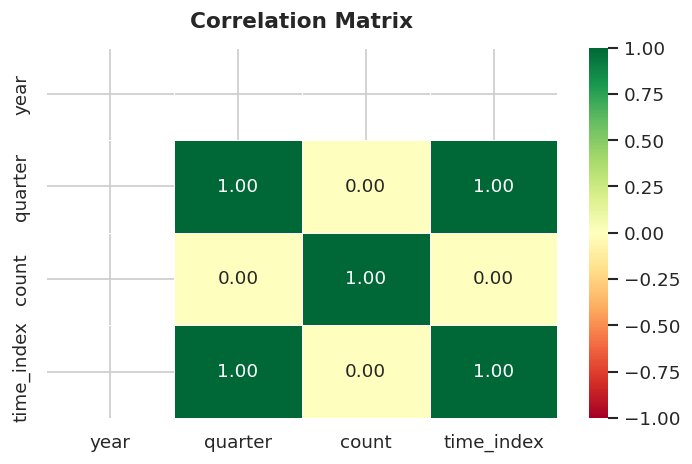

In [14]:
# ── Chart 4: Correlation heatmap ─────────────────────────────────
# sns.heatmap() shows how strongly each pair of numeric columns is correlated
fig, ax = plt.subplots(figsize=(6, 4))

corr_matrix = df[['year', 'quarter', 'count', 'time_index']].corr()  # .corr() → correlation matrix

sns.heatmap(
    corr_matrix,
    annot=True,          # show numbers inside cells
    fmt='.2f',           # 2 decimal places
    cmap='RdYlGn',       # color map: red (negative) → yellow (0) → green (positive)
    linewidths=0.5,
    ax=ax,
    vmin=-1, vmax=1      # fix color scale from -1 to 1
)
ax.set_title('Correlation Matrix', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

---
## Step 6 — Machine Learning: Forecast to 2030

### 🤖 Why Linear Regression?
Our quarterly data shows a **clear upward linear trend** — the count increases steadily each quarter.
Linear Regression finds the best-fit straight line: `y = mx + b`
- `y` = predicted enterprise count
- `x` = time_index (our engineered feature)
- `m` = slope (how much count increases per quarter)
- `b` = intercept

### 🔧 Sklearn Methods Used

| Method | What it does |
|---|---|
| `LinearRegression()` | Creates the model object |
| `.fit(X, y)` | **Trains** the model — finds the best `m` and `b` |
| `.predict(X)` | Uses the trained model to make predictions |
| `.coef_` | Returns the slope `m` |
| `.intercept_` | Returns the intercept `b` |
| `r2_score(y_true, y_pred)` | R² score: how well model explains variance (0–1, higher=better) |
| `mean_squared_error(...)` | MSE: average squared error |
| `np.sqrt(mse)` | RMSE: square root of MSE (same unit as count) |

In [15]:
# ── 6a. Prepare training data ────────────────────────────────────
# X must be 2D: shape (n_samples, n_features) — that's why we use [['time_index']]
# y is 1D: shape (n_samples,)
X = quarterly[['time_index']].values   # shape: (4, 1) — 4 quarters, 1 feature
y = quarterly['count'].values          # shape: (4,)  — 4 target values

print(f'X shape: {X.shape}  →  {X.flatten()}')
print(f'y shape: {y.shape}  →  {y}')

X shape: (4, 1)  →  [8101 8102 8103 8104]
y shape: (4,)  →  [682598 709779 729269 774123]


In [16]:
# ── 6b. Train the model ───────────────────────────────────────────
model = LinearRegression()    # Create model object
model.fit(X, y)               # .fit() → trains the model on our data

print(f'Model equation:  count = {model.coef_[0]:,.0f} × time_index + ({model.intercept_:,.0f})')
print(f'\nSlope     (m) = {model.coef_[0]:,.0f}  → enterprises added per quarter')
print(f'Intercept (b) = {model.intercept_:,.0f}')

Model equation:  count = 29,406 × time_index + (-237,542,224)

Slope     (m) = 29,406  → enterprises added per quarter
Intercept (b) = -237,542,224


In [17]:
# ── 6c. Evaluate the model ────────────────────────────────────────
y_pred = model.predict(X)     # .predict() → generate predictions on training data

r2   = r2_score(y, y_pred)                        # R² score (0 to 1)
mse  = mean_squared_error(y, y_pred)              # Mean Squared Error
rmse = np.sqrt(mse)                               # Root Mean Squared Error

print('── Model Evaluation ──────────────────')
print(f'R² Score : {r2:.4f}   (1.0 = perfect, >0.9 = excellent)')
print(f'RMSE     : {rmse:,.0f}   (average error in number of enterprises)')
print()

# Quick interpretation
if r2 >= 0.95:
    print('✅ Excellent fit — the trend is very linear and consistent.')
elif r2 >= 0.80:
    print('✅ Good fit — the model captures the main trend.')
else:
    print('⚠️  Moderate fit — consider polynomial regression or more data.')

── Model Evaluation ──────────────────
R² Score : 0.9702   (1.0 = perfect, >0.9 = excellent)
RMSE     : 5,760   (average error in number of enterprises)

✅ Excellent fit — the trend is very linear and consistent.


In [18]:
# ── 6d. Generate future predictions (2026 → 2030) ────────────────
future_rows = []
for yr in range(2026, 2031):          # years 2026 to 2030
    for qr in range(1, 5):            # quarters 1 to 4
        ti = yr * 4 + qr              # same formula as before
        future_rows.append({
            'year': yr,
            'quarter': qr,
            'label': f'{yr}-Q{qr}',
            'time_index': ti
        })

future_df = pd.DataFrame(future_rows)
future_df['predicted'] = model.predict(future_df[['time_index']].values)

# Annual totals
yearly_pred = future_df.groupby('year')['predicted'].sum()

print('── Forecast: Annual Total Enterprises ──')
for yr, val in yearly_pred.items():
    growth = ((val / quarterly['count'].sum()) - 1) * 100
    print(f'  {yr}: {val:>12,.0f}  enterprises  ({growth:+.1f}% vs 2025 total)')

── Forecast: Annual Total Enterprises ──
  2026:    3,366,273  enterprises  (+16.2% vs 2025 total)
  2027:    3,836,777  enterprises  (+32.5% vs 2025 total)
  2028:    4,307,281  enterprises  (+48.7% vs 2025 total)
  2029:    4,777,785  enterprises  (+65.0% vs 2025 total)
  2030:    5,248,289  enterprises  (+81.2% vs 2025 total)


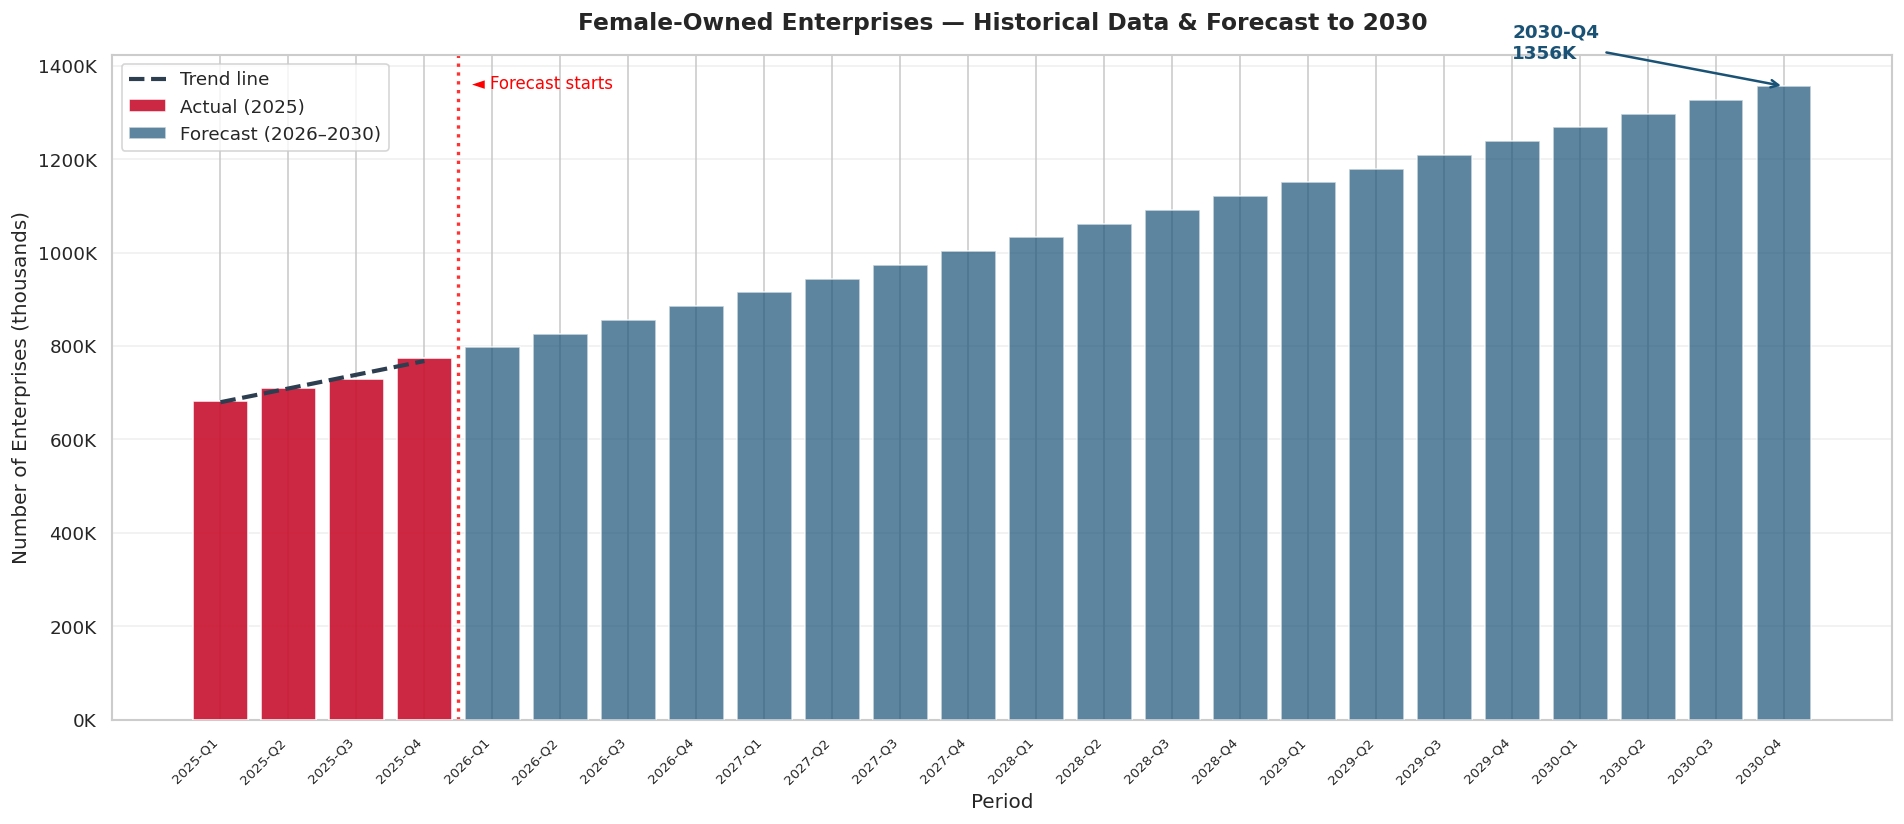

In [19]:
# ── 6e. Forecast visualization ───────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))

# Historical actual data (bars)
x_hist = range(len(quarterly))
ax.bar(x_hist, quarterly['count'] / 1000,
       color=PALETTE[0], alpha=0.9, label='Actual (2025)', zorder=3)

# Trend line over historical data
ax.plot(x_hist, y_pred / 1000,
        color='#2C3E50', linewidth=2.5, linestyle='--',
        label='Trend line', zorder=4)

# Future predicted data (bars)
x_future = range(len(quarterly), len(quarterly) + len(future_df))
ax.bar(x_future, future_df['predicted'] / 1000,
       color=PALETTE[2], alpha=0.7, label='Forecast (2026–2030)', zorder=3)

# Vertical line separating actual from forecast
ax.axvline(x=len(quarterly) - 0.5, color='red', linestyle=':', linewidth=2, alpha=0.8)
ax.text(len(quarterly) - 0.3, ax.get_ylim()[1] * 0.97,
        '◄ Forecast starts', color='red', fontsize=10, va='top')

# X-axis labels
all_labels = quarterly['label'].tolist() + future_df['label'].tolist()
ax.set_xticks(range(len(all_labels)))
ax.set_xticklabels(all_labels, rotation=45, ha='right', fontsize=8)

# Annotate 2030-Q4
last_x   = len(quarterly) + len(future_df) - 1
last_val = future_df.iloc[-1]['predicted']
ax.annotate(
    f"2030-Q4\n{last_val/1000:.0f}K",
    xy=(last_x, last_val / 1000),
    xytext=(last_x - 4, last_val / 1000 + 60),
    arrowprops=dict(arrowstyle='->', color=PALETTE[2], lw=1.5),
    fontsize=11, color=PALETTE[2], fontweight='bold'
)

ax.set_title('Female-Owned Enterprises — Historical Data & Forecast to 2030',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Period')
ax.set_ylabel('Number of Enterprises (thousands)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 7 — Results Summary

### 📊 Key Findings

| Quarter | Actual Count | Growth vs Q1 |
|---|---|---|
| 2025-Q1 | 682,598 | baseline |
| 2025-Q2 | 709,779 | +4.0% |
| 2025-Q3 | 729,269 | +6.8% |
| 2025-Q4 | 774,123 | +13.4% |

### 🏆 Top 3 Regions (2025 Total)
| Region | Total Enterprises |
|---|---|
| Riyadh Region | 1,282,147 |
| Makkah Region | 478,927 |
| Eastern Province | 306,941 |

### 🏢 Enterprise Size Breakdown
| Size | Count | Share |
|---|---|---|
| Micro | 2,706,698 | ~94% |
| Small | 169,908 | ~6% |
| Medium | 16,827 | ~0.6% |
| Large | 2,336 | ~0.08% |

### 🤖 Model Performance
| Metric | Value | Interpretation |
|---|---|---|
| R² Score | 0.9702 | Excellent — model explains 97% of variance |
| RMSE | ~5,760 | Average prediction error |

### 🔮 2030 Forecast (Annual Totals)
| Year | Predicted Total |
|---|---|
| 2026 | ~3.4 million |
| 2027 | ~3.8 million |
| 2028 | ~4.3 million |
| 2029 | ~4.8 million |
| **2030** | **~5.2 million** |

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [20]:
# ── Final summary printout ────────────────────────────────────────
print('=' * 55)
print('   FEMALE-OWNED ENTERPRISES — PROJECT SUMMARY')
print('=' * 55)
print(f'\n  Dataset rows (after cleaning) : {df.shape[0]:,}')
print(f'  Regions                       : {df["region"].nunique()}')
print(f'  Economic activities           : {df["activity"].nunique()}')
print(f'\n  Model  →  R² = {r2:.4f}  |  RMSE = {rmse:,.0f}')
print(f'  Slope  →  +{model.coef_[0]:,.0f} enterprises per quarter')
print()
print('  2030 Annual Forecast:')
for yr, val in yearly_pred.items():
    print(f'    {yr}  →  {val:>12,.0f} enterprises')
print()
print('  Forecast 2030-Q4 (single quarter):')
print(f'    {future_df.iloc[-1]["predicted"]:,.0f} enterprises')
print('=' * 55)

   FEMALE-OWNED ENTERPRISES — PROJECT SUMMARY

  Dataset rows (after cleaning) : 13,069
  Regions                       : 13
  Economic activities           : 89

  Model  →  R² = 0.9702  |  RMSE = 5,760
  Slope  →  +29,406 enterprises per quarter

  2030 Annual Forecast:
    2026  →     3,366,273 enterprises
    2027  →     3,836,777 enterprises
    2028  →     4,307,281 enterprises
    2029  →     4,777,785 enterprises
    2030  →     5,248,289 enterprises

  Forecast 2030-Q4 (single quarter):
    1,356,182 enterprises
